# 7. Clustering: Segmentación de Clientes

**Punto de partida:** el mismo dataset preprocesado por `3_FeatureEngineering.ipynb` (`../data/preprocessed_data.csv`).

**Objetivo del notebook:** hasta ahora el proyecto trabajó con aprendizaje **supervisado** — el dataset siempre tuvo una variable objetivo conocida (`churn` en clasificación, `MonthlyCharges` en regresión). Este módulo introduce el aprendizaje **no supervisado**: agrupar clientes por similitud **sin usar ninguna variable objetivo**, para descubrir segmentos naturales en la base de clientes.

### Nota importante sobre el nombre de las técnicas
En la propuesta de este módulo se mencionó **KNN** como una de las técnicas a implementar. Vale la pena aclarar una confusión muy común:

- **KNN (K-Nearest Neighbors)** es un algoritmo **supervisado**: clasifica o predice un valor nuevo   mirando las etiquetas de sus `k` vecinos más cercanos. Necesita un `target` para funcionar, por lo que   **no es un algoritmo de clustering**.
- **K-Means** es el algoritmo de partición más usado en clustering: agrupa los datos en `k` grupos según   cercanía a un centroide, **sin ninguna etiqueta**.

Ambos usan la misma idea de "distancia", pero resuelven problemas distintos. Como el objetivo del módulo es explícitamente no supervisado, este notebook implementa **K-Means** en lugar de KNN. Donde sí aparece la lógica de "vecinos más cercanos" es como herramienta auxiliar para calibrar **DBSCAN** (ver más adelante), no como técnica de clustering en sí misma.

### Algoritmos que se desarrollan
| Algoritmo | Enfoque | Requiere definir `k` | Detecta outliers |
|---|---|---|---|
| **K-Means** | Basado en partición (centroides) | Sí | No |
| **DBSCAN** | Basado en densidad | No | Sí (los marca como "ruido") |

Se reutilizan `pandas`, `numpy`, `matplotlib` y `seaborn` para datos y visualización. De `scikit-learn`:
- `StandardScaler`: escalamiento, indispensable en algoritmos basados en distancia.
- `PCA`: reducción de dimensionalidad, usada aquí solo para poder **visualizar** los clusters en 2D.
- `KMeans`, `DBSCAN`: los dos algoritmos de clustering del notebook.
- `NearestNeighbors`: no es un clasificador aquí, se usa como herramienta auxiliar para calibrar el   parámetro `eps` de DBSCAN.
- `silhouette_score`, `davies_bouldin_score`: métricas para evaluar qué tan buena es una partición en   clusters, el equivalente en clustering a las métricas de clasificación/regresión ya usadas.

In [1]:
# Plomería del entorno (no es parte del análisis): se fija la versión de
# scikit-learn. Los modelos serializados en ../models/*.pkl se guardaron con la
# 1.9.0, y joblib.load() advierte o falla al abrirlos con una versión distinta.
# %pip install -q scikit-learn==1.9.0

# import sklearn
# print("scikit-learn:", sklearn.__version__)
# if sklearn.__version__ != "1.9.0":
#     print("Versión distinta a la esperada (1.9.0).")
#     print("En Colab: menú Entorno de ejecución > Reiniciar sesión, y ejecuta de nuevo esta celda.")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## Parámetros del experimento

- **`target`**: `"churn"` — no se usa para entrenar ningún modelo de este notebook; se conserva únicamente para interpretar los clusters *después* de formarlos (ver más adelante).
- **`RANDOM_STATE`**: fija la inicialización aleatoria de K-Means, para que los resultados sean reproducibles entre ejecuciones.

In [3]:
target = "churn"
RANDOM_STATE = 123

## Cargar datos

Se reutiliza directamente `preprocessed_data.csv`, el mismo archivo que consumen `4_Modeling.ipynb`, `5_ModelOptimization.ipynb` y `6_Regression.ipynb`.

In [4]:
fName = "../data/preprocessed_data.csv"
data = pd.read_csv(fName, sep=",", na_values=["", " ", "-", "NA"])
data.set_index("customerID", inplace=True)
print(f"Datos cargados desde {fName} con shape={data.shape}")
data.head()

Datos cargados desde ../data/preprocessed_data.csv con shape=(7043, 25)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check,churn
customerID,,,,,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,1,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,1,0,1,0,0,0,0,1,0,0
5575-GNVDE,0,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1,0,0,1,0,0,0,0,1,0
3668-QPYBK,0,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,1,0,1,0,0,0,0,0,1,1
7795-CFOCW,0,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1,0,0,1,0,1,0,0,0,0
9237-HQITU,1,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,0,1,1,0,0,0,0,1,0,1


## Separar variables

A diferencia de los módulos anteriores, aquí **no hay `X_train`/`X_test`**: el clustering no se evalúa contra un conjunto de prueba separado, porque no está prediciendo nada que se pueda "acertar" o "fallar" — agrupa la totalidad de los datos disponibles según su similitud.

In [5]:
feat = [c for c in data if c != target]
X = data[feat].copy()
y_churn = data[target].copy()  # se guarda aparte SOLO para interpretar los clusters al final; no se usa para entrenar

print(f"{X.shape=}")
X.head()

X.shape=(7043, 24)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check
customerID,,,,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,1,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,1,0,1,0,0,0,0,1,0
5575-GNVDE,0,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1,0,0,1,0,0,0,0,1
3668-QPYBK,0,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,1,0,1,0,0,0,0,0,1
7795-CFOCW,0,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1,0,0,1,0,1,0,0,0
9237-HQITU,1,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,0,1,1,0,0,0,0,1,0


## Escalamiento de variables

Tanto K-Means como DBSCAN se basan en **distancias** (euclidiana, por defecto) entre observaciones. Si las variables no están en la misma escala, las de mayor rango (`tenure`: 0–72, `MonthlyCharges`: ~18–118) dominarían por completo la distancia calculada, opacando a las variables binarias (0/1).

Por eso aquí se escalan **todas** las variables, no solo las continuas como se hizo en `4_Modeling.ipynb` (donde solo se escalaba `tenure` y `MonthlyCharges`, y únicamente para la Regresión Logística). Las variables binarias ya están en el rango [0,1], pero dejarlas sin escalar mientras las continuas sí se estandarizan les restaría peso relativo en el cálculo de distancia — por eso se escala el conjunto completo.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

X_scaled.describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
gender,0.0,1.0,-0.99,1.01
seniorcitizen,-0.0,1.0,-0.44,2.27
partner,0.0,1.0,-0.97,1.03
dependents,0.0,1.0,-0.65,1.53
tenure,-0.0,1.0,-1.32,1.61
phoneservice,0.0,1.0,-3.05,0.33
multiplelines,-0.0,1.0,-0.85,1.17
onlinesecurity,-0.0,1.0,-0.63,1.58
onlinebackup,0.0,1.0,-0.73,1.38
deviceprotection,0.0,1.0,-0.72,1.38


## Reducción de dimensionalidad para visualización (PCA)

El dataset tiene bastantes variables tras el One-Hot Encoding (revisa `X.shape` más arriba) — demasiadas para visualizar directamente en un plano. Se usa **PCA (Análisis de Componentes Principales)** para proyectar los datos a 2 dimensiones **solo con fines de visualización**.

**Importante:** el clustering en sí se entrena sobre el espacio completo escalado (`X_scaled`), no sobre esta proyección — reducir a 2D antes de agrupar perdería información y podría fusionar grupos que en el espacio original están separados. PCA se usa aquí únicamente para *dibujar* el resultado, después de que K-Means y DBSCAN ya agruparon usando todas las variables.

Varianza explicada por los 2 componentes: 33.2%
(Es normal que sea un porcentaje moderado: hay muchas variables binarias comprimidas en solo 2 ejes;
 la posición relativa de los puntos es aproximada, no una representación exacta del espacio original.)


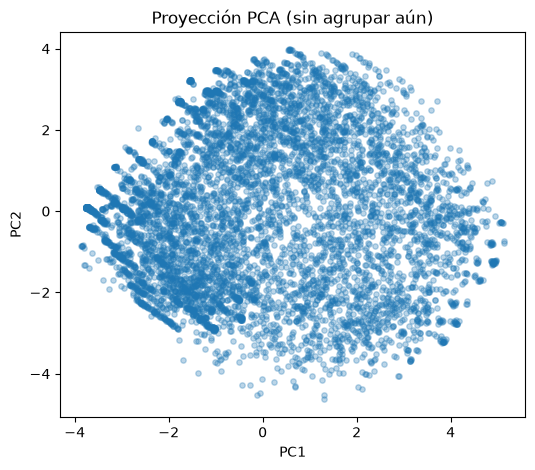

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)

varianza_explicada = pca.explained_variance_ratio_.sum()
print(f"Varianza explicada por los 2 componentes: {varianza_explicada:.1%}")
print("(Es normal que sea un porcentaje moderado: hay muchas variables binarias comprimidas en solo 2 ejes;")
print(" la posición relativa de los puntos es aproximada, no una representación exacta del espacio original.)")

plt.figure(figsize=(6, 5))
plt.scatter(X_pca["PC1"], X_pca["PC2"], alpha=0.3, s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA (sin agrupar aún)")
plt.show()

## K-Means

### ¿Cómo funciona?
K-Means agrupa las observaciones en `k` clusters, cada uno representado por un **centroide** (el promedio de los puntos que le pertenecen). El algoritmo itera dos pasos hasta converger: (1) asignar cada punto al centroide más cercano, (2) recalcular cada centroide como el promedio de los puntos recién asignados. El objetivo que minimiza es la **inercia** (WCSS, *within-cluster sum of squares*): qué tan compactos son los clusters resultantes.

**Supuestos y limitaciones:** requiere definir `k` de antemano, asume clusters de forma aproximadamente esférica y de tamaño similar, y es sensible a la inicialización de los centroides (`scikit-learn` mitiga esto con `n_init`, que prueba varias inicializaciones y conserva la mejor).

### Elegir k: método del codo

Se entrena K-Means para varios valores de `k` y se grafica la inercia resultante. A medida que `k` crece, la inercia siempre baja (más clusters, grupos más compactos) — el objetivo es encontrar el punto donde agregar un cluster adicional deja de reducir la inercia de forma significativa (el "codo" de la curva).

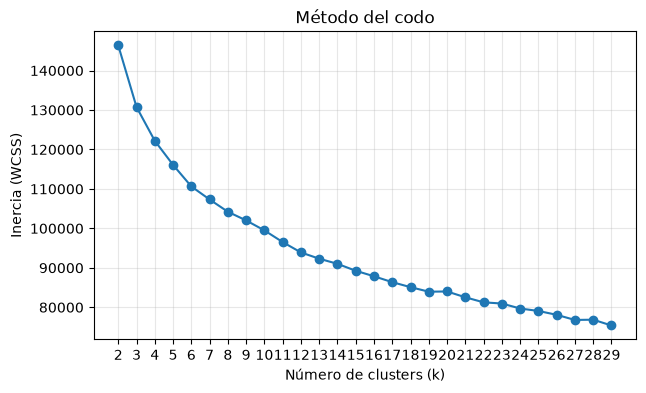

In [10]:
inertias = []
k_range = range(2, 30)

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans_k.fit(X_scaled)
    inertias.append(kmeans_k.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (WCSS)")
plt.title("Método del codo")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()

### Elegir k: coeficiente de silueta

El método del codo puede ser ambiguo (el "codo" no siempre es obvio). El **coeficiente de silueta** complementa ese criterio: para cada punto, compara qué tan cerca está de los puntos de su propio cluster frente a los del cluster más cercano. Va de `-1` a `1`; valores altos indican clusters compactos y bien separados entre sí.

**Referencia para interpretar el valor** (no es un umbral universal, pero es una guía común — Kaufman & Rousseeuw): > 0.5 estructura fuerte, 0.25–0.5 estructura débil o razonable, < 0.25 sin estructura sustancial. Te sirve para juzgar si el resultado que obtengas en tu propia ejecución es alto o bajo, no solo para compararlo entre valores de `k`.

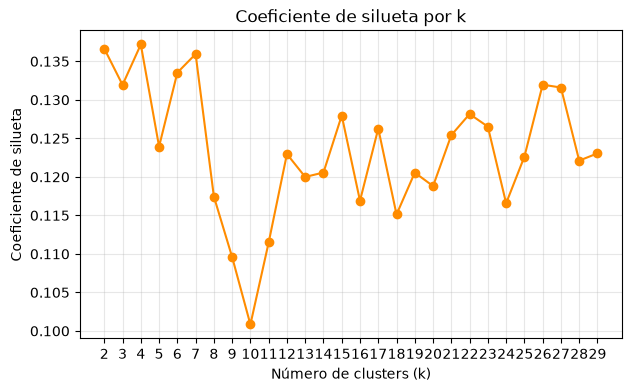

In [11]:
silhouette_scores = []

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans_k.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels_k))

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de silueta")
plt.title("Coeficiente de silueta por k")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()

### Selección final de k

Se elige el valor de `k` donde la inercia deja de caer marcadamente **y** el coeficiente de silueta es relativamente alto. **Ajusta `k_final` según lo que observes al ejecutar las dos celdas anteriores** — aquí se deja `k_final = 4` como punto de partida razonable para este dataset, pero la elección final depende de las gráficas generadas en tu ejecución.

In [12]:
k_final = 4  # ajustar según el método del codo y el coeficiente de silueta obtenidos arriba

kmeans = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
data["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

print(f"Silhouette score (k={k_final}): {silhouette_score(X_scaled, data['cluster_kmeans']):.3f}")
data["cluster_kmeans"].value_counts().sort_index()

Silhouette score (k=4): 0.137


cluster_kmeans
0    1758
1    1576
2    1582
3    2127
Name: count, dtype: int64

### Visualización de los clusters (proyección PCA)

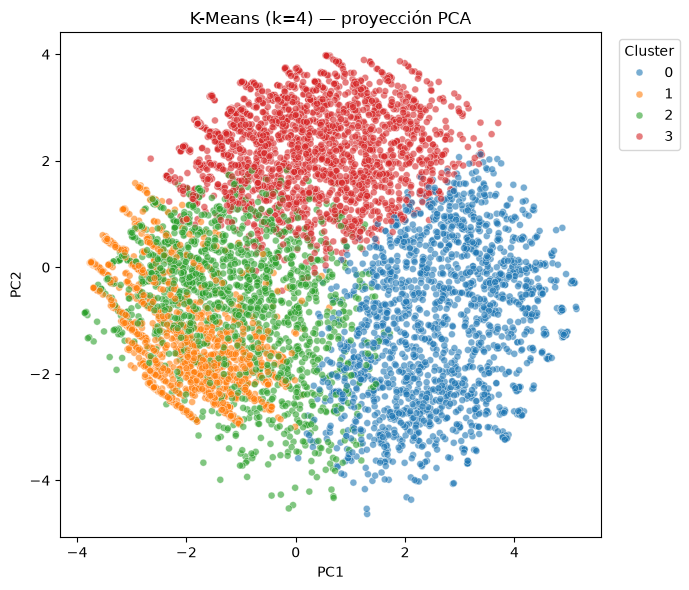

In [13]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_pca["PC1"], y=X_pca["PC2"], hue=data["cluster_kmeans"], palette="tab10", alpha=0.6, s=25)
plt.title(f"K-Means (k={k_final}) — proyección PCA")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Perfilar los clusters

Se calcula el promedio de cada variable por cluster — el paso que realmente convierte un cluster en un **segmento de negocio interpretable**: ¿qué caracteriza a cada grupo? ¿clientes nuevos vs. antiguos? ¿con o sin servicios adicionales? ¿de qué tipo de contrato?

In [14]:
perfil_kmeans = data.groupby("cluster_kmeans")[feat].mean().round(2)
perfil_kmeans

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,,,,
0,0.50,0.15,0.73,0.40,58.23,0.94,0.67,0.63,0.70,0.75,0.68,0.75,0.76,0.64,89.51,0.46,0.54,0.05,0.41,0.54,0.37,0.36,0.19,0.08
1,0.49,0.03,0.49,0.43,30.39,1.00,0.22,0.00,0.00,0.00,0.00,0.00,0.00,0.29,22.49,0.02,0.02,0.35,0.24,0.41,0.22,0.21,0.07,0.49
2,0.49,0.11,0.34,0.25,20.47,0.64,0.14,0.37,0.33,0.28,0.34,0.25,0.25,0.56,49.99,1.00,0.00,0.75,0.19,0.06,0.16,0.18,0.35,0.32
3,0.50,0.30,0.38,0.15,21.31,1.00,0.57,0.15,0.31,0.31,0.15,0.47,0.46,0.80,86.61,0.00,1.00,0.97,0.03,0.00,0.14,0.13,0.64,0.09


### Churn observado por cluster (validación externa)

Aunque `churn` no se usó para entrenar el modelo, es interesante revisarlo *después* de formar los clusters: si algún segmento concentra una tasa de abandono mucho mayor que el resto, el clustering estaría descubriendo, de forma no supervisada, una estructura relevante para el mismo problema de negocio trabajado en los módulos de clasificación.

In [15]:
tasa_churn_por_cluster = (data.groupby("cluster_kmeans")[target].mean() * 100).round(1)
tasa_churn_por_cluster.name = "% churn"
tasa_churn_por_cluster.to_frame()

,% churn
cluster_kmeans,
0,9.6
1,8.1
2,26.5
3,54.3


## DBSCAN

### ¿Cómo funciona?
A diferencia de K-Means, DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) no requiere definir `k` de antemano: agrupa puntos que están densamente conectados entre sí, y marca como **ruido** (`label = -1`) los puntos que no pertenecen a ninguna región densa. Dos parámetros lo controlan:

- **`eps`**: radio máximo de vecindad.
- **`min_samples`**: número mínimo de puntos dentro de ese radio para considerar una región "densa".

**Ventajas** frente a K-Means: detecta outliers explícitamente, encuentra clusters de forma no esférica, no exige fijar el número de grupos de antemano.
**Desventajas**: es más sensible a la escala y a la elección de `eps`; en espacios de muchas dimensiones (como este, tras el One-Hot Encoding) las distancias tienden a volverse más uniformes entre todos los puntos — la llamada *maldición de la dimensionalidad* — lo que puede dificultar encontrar un `eps` que separe bien los grupos.

### Elegir eps: gráfica de k-distancia

Una forma sistemática de elegir `eps` es calcular, para cada punto, la distancia a su `k`-ésimo vecino más cercano (usando `min_samples` como `k`), ordenar esas distancias de menor a mayor, y buscar el "codo" de la curva — el punto de mayor curvatura suele ser un buen candidato para `eps`.

> Aquí es donde aparece **k-Nearest Neighbors como herramienta auxiliar** (`NearestNeighbors` de `scikit-learn`), no como algoritmo de clustering en sí, sino como paso de calibración de DBSCAN.

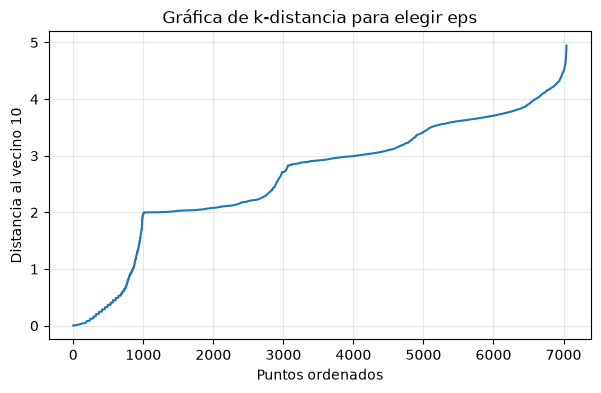

In [16]:
MIN_SAMPLES = 10

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_scaled)
distancias, _ = nn.kneighbors(X_scaled)

k_distancias = np.sort(distancias[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distancias)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al vecino {MIN_SAMPLES}")
plt.title("Gráfica de k-distancia para elegir eps")
plt.grid(alpha=0.3)
plt.show()

### Entrenar DBSCAN

Se elige `eps` en el punto de mayor curvatura de la gráfica anterior. **Ajusta `EPS` según lo que observes** — se deja un valor de partida razonable para este dataset.

In [17]:
EPS = 3.0  # ajustar según la gráfica de k-distancia obtenida arriba

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
data["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

etiquetas_unicas = set(data["cluster_dbscan"])
n_clusters_dbscan = len(etiquetas_unicas) - (1 if -1 in etiquetas_unicas else 0)
n_ruido = int((data["cluster_dbscan"] == -1).sum())

print(f"Clusters encontrados: {n_clusters_dbscan}")
print(f"Puntos marcados como ruido: {n_ruido} ({n_ruido / len(data):.1%})")
data["cluster_dbscan"].value_counts().sort_index()

Clusters encontrados: 27
Puntos marcados como ruido: 1857 (26.4%)


cluster_dbscan
-1     1857
 0      140
 1      715
 2     1590
 3       75
 4      193
 5      382
 6      266
 7      167
 8       94
 9      339
 10     178
 11      78
 12     252
 13      27
 14     252
 15      23
 16      35
 17      17
 18      14
 19      56
 20     128
 21      22
 22      64
 23      29
 24      23
 25      13
 26      14
Name: count, dtype: int64

### Visualización de los clusters DBSCAN (proyección PCA)

Los puntos de ruido (`-1`) se muestran en gris para distinguirlos de los clusters reales.

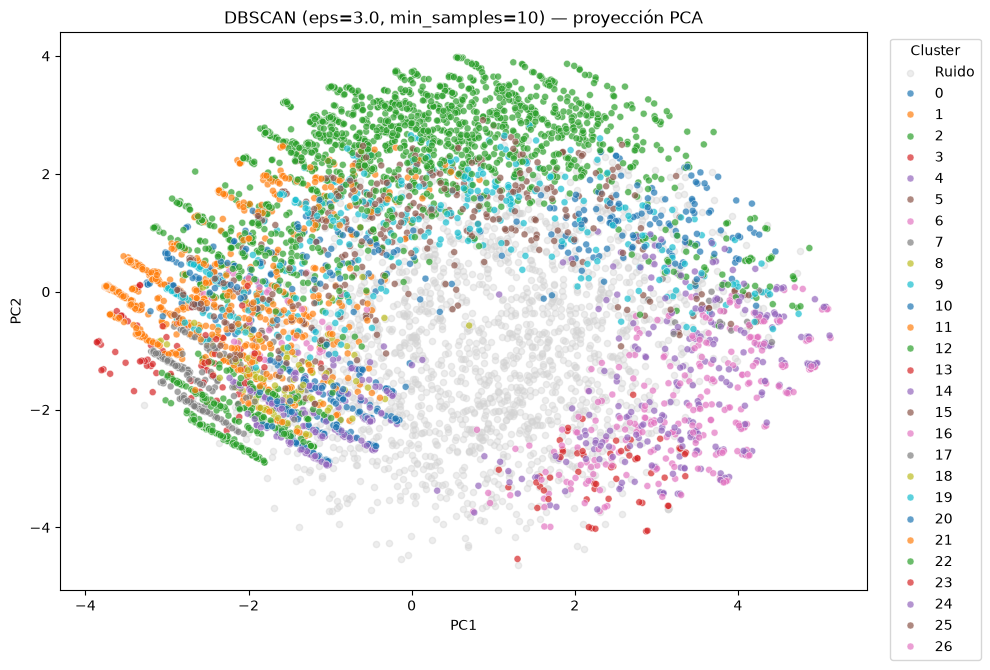

In [18]:
es_ruido = data["cluster_dbscan"] == -1

plt.figure(figsize=(10, 7))
plt.scatter(X_pca.loc[es_ruido, "PC1"], X_pca.loc[es_ruido, "PC2"],
            color="lightgray", alpha=0.4, s=20, label="Ruido")
sns.scatterplot(
    x=X_pca.loc[~es_ruido, "PC1"], y=X_pca.loc[~es_ruido, "PC2"],
    hue=data.loc[~es_ruido, "cluster_dbscan"], palette="tab10", alpha=0.7, s=25
)
plt.title(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) — proyección PCA")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Perfilar los clusters DBSCAN

Se excluyen los puntos de ruido del perfilamiento, ya que por definición no pertenecen a ningún grupo cohesivo.

In [19]:
perfil_dbscan = data.loc[~es_ruido].groupby("cluster_dbscan")[feat].mean().round(2)
perfil_dbscan

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check
cluster_dbscan,,,,,,,,,,,,,,,,,,,,,,,,
0,0.59,0.19,0.31,0.13,13.79,0.0,0.00,0.09,0.24,0.19,0.14,0.35,0.41,0.73,35.79,1.00,0.00,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.47,0.06,0.22,0.22,8.42,1.0,0.17,0.11,0.09,0.08,0.10,0.09,0.08,0.46,43.13,0.34,0.20,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.49,0.28,0.35,0.15,17.03,1.0,0.50,0.14,0.27,0.26,0.12,0.43,0.43,0.77,78.81,0.16,0.80,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.48,0.05,0.20,0.23,7.65,0.0,0.00,0.27,0.25,0.20,0.27,0.07,0.07,0.41,31.16,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.52,0.07,0.64,0.48,52.88,1.0,0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.28,22.75,0.00,0.02,0.0,0.0,1.0,0.0,1.0,0.0,0.0
5,0.54,0.14,0.42,0.20,21.93,1.0,0.47,0.13,0.25,0.20,0.09,0.29,0.29,0.69,68.17,0.19,0.64,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6,0.49,0.09,0.80,0.45,65.52,1.0,0.79,0.86,0.80,0.86,0.88,0.82,0.79,0.59,93.03,0.56,0.44,0.0,0.0,1.0,0.0,1.0,0.0,0.0
7,0.45,0.02,0.48,0.43,23.04,1.0,0.10,0.00,0.00,0.00,0.00,0.00,0.00,0.23,20.85,0.02,0.00,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8,0.49,0.05,0.48,0.44,36.74,1.0,0.22,0.00,0.00,0.00,0.01,0.00,0.00,0.35,23.51,0.03,0.03,0.0,1.0,0.0,1.0,0.0,0.0,0.0


## K-Means vs. DBSCAN: comparación

Se calcula el coeficiente de silueta de ambos algoritmos sobre el mismo espacio escalado (excluyendo el ruido en el caso de DBSCAN, ya que la métrica no está definida para puntos sin cluster) para poder comparar objetivamente qué tan compactos y separados quedaron los grupos en cada enfoque.

In [20]:
silhouette_kmeans = silhouette_score(X_scaled, data["cluster_kmeans"])

if n_clusters_dbscan >= 2:
    silhouette_dbscan = silhouette_score(X_scaled.loc[~es_ruido], data.loc[~es_ruido, "cluster_dbscan"])
else:
    silhouette_dbscan = float("nan")

comparacion = pd.DataFrame({
    "Algoritmo": ["K-Means", "DBSCAN"],
    "N° de clusters": [k_final, n_clusters_dbscan],
    "Puntos sin asignar": [0, n_ruido],
    "Silhouette score": [round(silhouette_kmeans, 3), round(silhouette_dbscan, 3)],
})
comparacion

,Algoritmo,N° de clusters,Puntos sin asignar,Silhouette score
0,K-Means,4,0,0.137
1,DBSCAN,27,1857,0.155


### Interpretación

Con la referencia de la sección de K-Means: ambos valores de silueta obtenidos (0.137 en K-Means, 0.155 en DBSCAN) caen por debajo de 0.25 — es decir, en la zona de "sin estructura sustancial" fuerte. Esto no invalida el ejercicio: los clusters igual muestran diferencias claras de negocio (tasa de churn, tenure, tipo de contrato), pero conviene comunicarlos como segmentos útiles para priorizar, no como grupos estadísticamente muy separados entre sí. Es una limitación esperable en un dataset con muchas variables binarias tras el One-Hot Encoding, no necesariamente un error de configuración.

K-Means obliga a asignar cada cliente a un grupo, incluso si no encaja bien en ninguno; DBSCAN es más honesto en ese sentido — el *ruido* que reporta puede señalar clientes con combinaciones de servicios atípicas, candidatos interesantes para una revisión manual en lugar de forzarlos dentro de un segmento que no los representa bien.

A cambio, DBSCAN en este dataset (de alta dimensionalidad tras el One-Hot Encoding) es más sensible a la elección de `eps`: puede terminar concentrando la mayoría de los puntos en un solo cluster grande si `eps` es demasiado alto, o marcando casi todo como ruido si es demasiado bajo. Vale la pena probar distintos valores de `eps` y `min_samples` y observar cómo cambia el resultado antes de quedarse con una configuración final.

## Guardar resultados

Se persisten los artefactos del experimento de clustering, siguiendo el mismo patrón usado en los módulos anteriores. Se usa el prefijo `clustering_` (y nombres de archivo específicos por algoritmo) para no sobrescribir los artefactos de clasificación (`4_Modeling.ipynb`) ni de regresión (`6_Regression.ipynb`) que ya viven en `../models/`.

Además de los modelos, se exporta a Excel la asignación de cluster por cliente — el insumo típico para que el equipo de negocio (o un tablero de Power BI) trabaje la segmentación sin depender de Python.

In [21]:
import joblib

joblib.dump({"scaler": scaler, "pca": pca}, "../models/clustering_preprocesamiento.pkl")
joblib.dump(kmeans, "../models/kmeans_clustering.pkl")
joblib.dump(dbscan, "../models/dbscan_clustering.pkl")

resultado_clusters = data[[target, "cluster_kmeans", "cluster_dbscan"]].reset_index()
fName_out = "../output/clusters_clientes.xlsx"
resultado_clusters.to_excel(fName_out, index=False)

print("Modelos de clustering guardados en ../models/")
print(f"Asignación de clusters exportada a {fName_out}")

Modelos de clustering guardados en ../models/
Asignación de clusters exportada a ../output/clusters_clientes.xlsx


## Conclusiones y siguientes pasos

Este notebook cubrió los dos enfoques principales de clustering: **K-Means** (basado en partición, requiere definir `k`) y **DBSCAN** (basado en densidad, detecta ruido). Próximos pasos posibles:

1. **Clustering jerárquico (Agglomerative Clustering)** como tercera técnica de comparación, útil para    explorar la estructura de agrupamiento a distintos niveles de granularidad (dendrograma).
2. **Selección sistemática de `eps`/`min_samples`**: recorrer una rejilla de combinaciones evaluando    `silhouette_score` en cada una, análogo en espíritu al `GridSearchCV` de `5_ModelOptimization.ipynb`    (aunque `scikit-learn` no trae un `GridSearchCV` nativo para clustering, al no existir un `y` contra    el cual optimizar).
3. **Perfiles de cluster más ricos**: boxplots por cluster de `tenure` y `MonthlyCharges`, y    distribución de variables categóricas clave (`Contract`, `InternetService`) por cluster, más allá    del promedio simple ya calculado.
4. **Uso de negocio**: los segmentos resultantes son un insumo natural para campañas de retención    diferenciadas — el mismo objetivo de negocio de `4_Modeling.ipynb`, abordado aquí desde una    perspectiva exploratoria en lugar de predictiva.